# 03 — Point-in-time alignment

This notebook compares three ways of aligning the Monday retail survey with upstream crude prices:

- **weekly (primary):** each retail Monday is paired with the most recent weekly-Friday crude
observation strictly before the survey.
- **daily_pit (robustness):** each retail Monday is paired with the most recent daily crude close
strictly before the survey.
- **leaky (contrast only):** each retail Monday is paired with the Friday of the same calendar
week. This alignment is deliberately invalid because that Friday occurs after the Monday survey.

The goal is to show how the choice of alignment affects the measured lag structure and to verify
that the production alignment cannot introduce look-ahead bias.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.point_in_time import align_retail_to_upstream
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, leaky_merge, load_series

# UPSTREAM_SERIES_ID ("WCOILWTICO") is the WEEKLY crude series' own ID — the daily series
# is a genuinely different FRED series, DCOILWTICO, not the same ID at a different freq.
DAILY_UPSTREAM_SERIES_ID = "DCOILWTICO"

COLOR_WEEKLY = "#2a78d6"
COLOR_DAILY_PIT = "#1baf7a"
COLOR_LEAKY = "#eb6834"
COLOR_RETAIL = "#eb6834"

retail_full = load_series(PROCESSED_DIR / "retail.csv", RETAIL_SERIES_ID, "weekly-mon")
weekly_upstream = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
daily_upstream_raw = load_series(PROCESSED_DIR / "crude.csv", DAILY_UPSTREAM_SERIES_ID, "daily")

# FRED's daily series has a row for every weekday, including market holidays — those rows
# carry a NaN value rather than being omitted (confirmed directly against the raw table:
# Good Friday 2024-03-29 has a row, value NaN). Dropping NaN before merging is required for
# daily_pit — without it, a backward asof search could land ON a holiday's NaN row instead
# of correctly skipping past it to the last real close.
daily_upstream = daily_upstream_raw.dropna(subset=["value"]).reset_index(drop=True)
print(f"daily upstream: {len(daily_upstream_raw)} rows pulled, {daily_upstream_raw['value'].isna().sum()} holiday NaNs dropped -> {len(daily_upstream)} usable")

# Boundary case, found by actually running this: retail's first date (2010-01-04) exactly
# coincides with daily_upstream's earliest available date — this project pulls from
# 2010-01-01 onward (fetch_series.START_DATE), so there is no daily close strictly before
# retail's very first Monday within the pulled window. align_retail_to_upstream correctly
# raises on that row (a real "no valid point-in-time match" case, not a leak). Trimming
# retail once, here, keeps weekly/daily_pit/leaky all built from the identical, safe date
# range — required for section 2c's row-for-row comparison to be meaningful.
retail = retail_full[retail_full["date"] > daily_upstream["date"].min()].reset_index(drop=True)
print(f"retail: {len(retail_full)} -> {len(retail)} rows after trimming the one date with no valid daily_pit lookback")

weekly = align_retail_to_upstream(retail, weekly_upstream, mode="weekly")
daily_pit = align_retail_to_upstream(retail, daily_upstream, mode="daily_pit")
leaky = leaky_merge(retail, weekly_upstream)
leaky["gap_days"] = (leaky["date"] - leaky["upstream_date"]).dt.days

ALIGNMENTS = {"weekly": weekly, "daily_pit": daily_pit, "leaky": leaky}
ALIGNMENT_COLORS = {"weekly": COLOR_WEEKLY, "daily_pit": COLOR_DAILY_PIT, "leaky": COLOR_LEAKY}

for name, df in ALIGNMENTS.items():
    print(f"{name:<10} {len(df)} rows, {df['value_upstream'].isna().sum()} unmatched")

daily upstream: 4327 rows pulled, 168 holiday NaNs dropped -> 4159 usable
retail: 866 -> 865 rows after trimming the one date with no valid daily_pit lookback
weekly     865 rows, 0 unmatched
daily_pit  865 rows, 0 unmatched
leaky      865 rows, 1 unmatched


## 1. One worked example
A single retail Monday is shown under the primary and leaky alignments. The retail date and retail
value are identical in both cases; only the upstream date, upstream value, and resulting date gap
change.

What this shows: the difference between a valid prior-week alignment and an invalid same-week
Friday alignment in one concrete observation.

In [2]:
EXAMPLE_DATE = pd.Timestamp("2022-06-13")  # a Monday during the 2022 crude spike, upstream moving fast that week

weekly_row = weekly[weekly["date"] == EXAMPLE_DATE].iloc[0]
leaky_row = leaky[leaky["date"] == EXAMPLE_DATE].iloc[0]

comparison = pd.DataFrame(
    {
        "weekly (prior week's Friday)": [weekly_row["date"].date(), weekly_row["upstream_date"].date(), weekly_row["value_upstream"], int(weekly_row["gap_days"])],
        "leaky (same week's Friday)": [leaky_row["date"].date(), leaky_row["upstream_date"].date(), leaky_row["value_upstream"], int(leaky_row["gap_days"])],
    },
    index=["retail_date", "upstream_date", "value_upstream", "gap_days (retail - upstream)"],
)
comparison

,weekly (prior week's Friday),leaky (same week's Friday)
retail_date,2022-06-13,2022-06-13
upstream_date,2022-06-10,2022-06-17
value_upstream,2.867381,2.772857
gap_days (retail - upstream),3,-4


## 2. Three alignments compared
The three alignments are compared using their lag profiles, change relationships, and calendar-date gaps.

### 2a. Lag profile
For each alignment, the correlation between the weekly retail change and lagged upstream changes is
calculated for lags 0–8.

What this shows: where the strongest observed relationship occurs in the lag structure. Under a
valid point-in-time alignment, lag 0 corresponds to the most recent upstream information available
before the retail survey. The deliberately leaky alignment shifts the upstream observation forward
by one weekly step, so the same relationship is expected to appear at lag 1 instead.

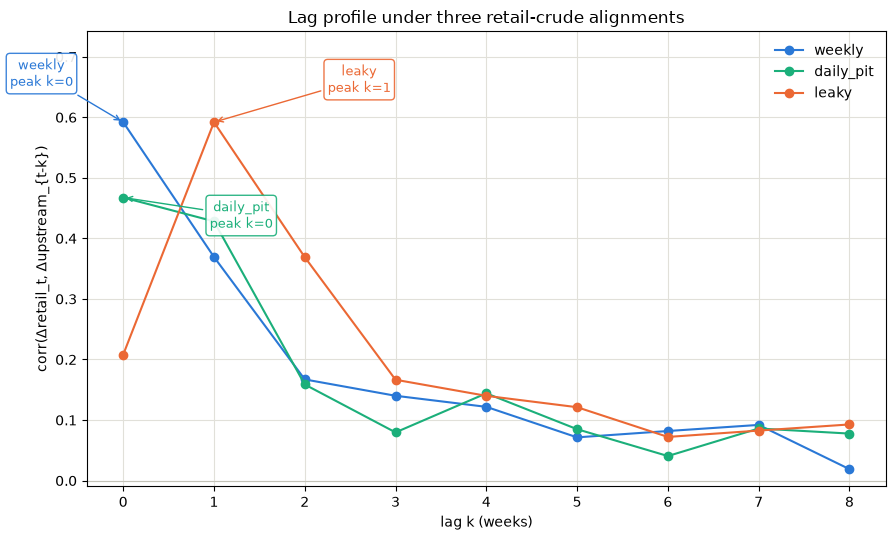

In [3]:
MAX_LAG = 8


def lag_correlation(merged: pd.DataFrame, k: int) -> float:
    """corr(delta_retail_t, delta_upstream_{t-k}) — shifting delta_upstream forward by k
    rows makes position t hold what was originally at t-k, so this is exactly the lagged
    correlation the profile needs, for any of the three alignments' merged tables.
    """
    delta_retail = merged["value_retail"].diff()
    delta_upstream = merged["value_upstream"].diff()
    return delta_retail.corr(delta_upstream.shift(k))


lag_table = pd.DataFrame(
    {name: [lag_correlation(df, k) for k in range(MAX_LAG + 1)] for name, df in ALIGNMENTS.items()},
    index=pd.RangeIndex(MAX_LAG + 1, name="lag"),
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for name in ALIGNMENTS:
    ax.plot(lag_table.index, lag_table[name], marker="o", color=ALIGNMENT_COLORS[name], label=name)

# Distinct offsets per series so labels don't collide — weekly's and leaky's peaks land
# at nearly the same height (0.592) at different lags, so a uniform offset overlapped them.
peak_annotation_offsets = {"weekly": (-0.9, 0.06), "daily_pit": (1.3, -0.05), "leaky": (1.6, 0.05)}
for name in ALIGNMENTS:
    peak_lag = lag_table[name].idxmax()
    peak_value = lag_table[name].max()
    dx, dy = peak_annotation_offsets[name]
    ax.annotate(
        f"{name}\npeak k={peak_lag}",
        xy=(peak_lag, peak_value),
        xytext=(peak_lag + dx, peak_value + dy),
        color=ALIGNMENT_COLORS[name],
        fontsize=9,
        ha="center",
        arrowprops={"arrowstyle": "->", "color": ALIGNMENT_COLORS[name], "lw": 1},
        bbox={"boxstyle": "round", "fc": "white", "ec": ALIGNMENT_COLORS[name], "alpha": 0.9},
    )

ax.set_xlabel("lag k (weeks)")
ax.set_ylabel("corr(Δretail_t, Δupstream_{t-k})")
ax.set_xticks(range(MAX_LAG + 1))
ax.set_ylim(top=lag_table.values.max() + 0.15)
ax.grid(True, color="#e1e0d9")
ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.legend(frameon=False)
ax.set_title("Lag profile under three retail-crude alignments", loc="center")
plt.tight_layout()
plt.show()

In [4]:
lag_table.round(3)

,weekly,daily_pit,leaky
lag,,,
0,0.592,0.468,0.208
1,0.369,0.428,0.592
2,0.167,0.159,0.369
3,0.140,0.080,0.167
4,0.122,0.144,0.140
5,0.071,0.085,0.121
6,0.082,0.041,0.072
7,0.092,0.086,0.083
8,0.019,0.078,0.093


### 2b. Scatter plot
For each alignment, weekly changes in upstream crude prices are plotted against weekly changes in
retail prices. The raw observations are shown together with an OLS fitted line and means from 20
equal-count bins.

What this shows: the binned means make the underlying relationship easier to see than the full
cloud of observations alone and allow the three alignments to be compared on the same scale.

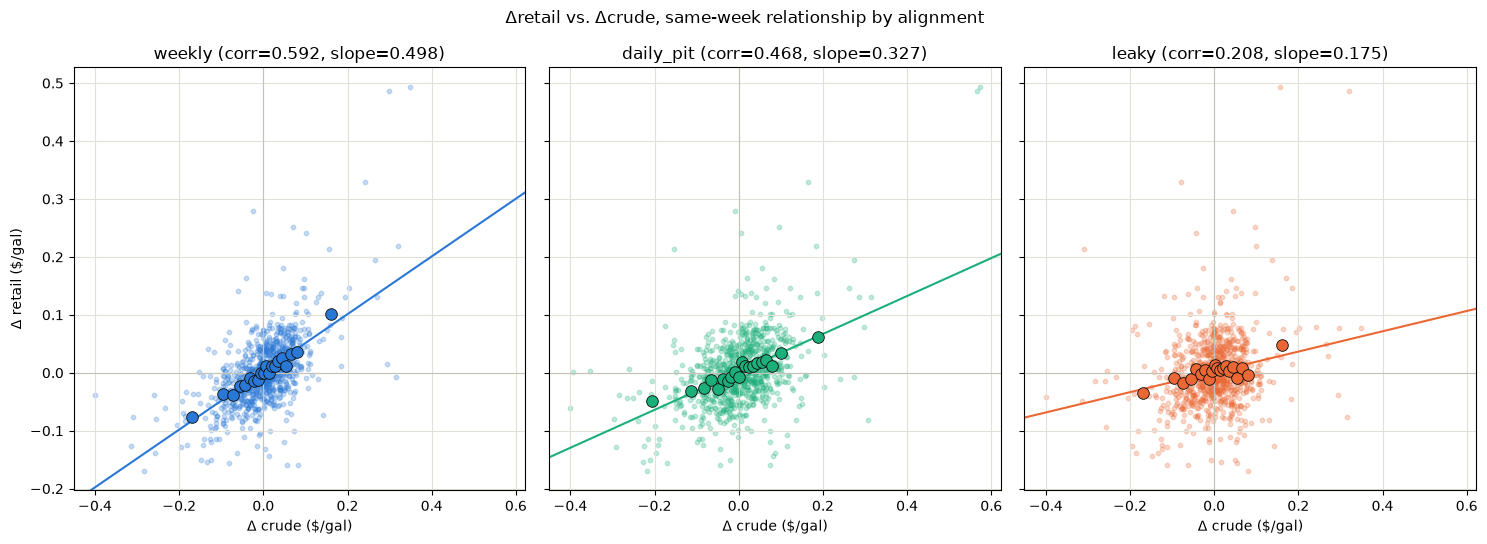

In [5]:
N_BINS = 20


def compute_deltas(merged: pd.DataFrame) -> pd.DataFrame:
    """Δupstream/Δretail as one frame, NaN-dropped jointly (not column-by-column) so the
    two series never desync — leaky in particular carries a real NaN (its final row has
    no forward match), and dropping each column's NaN independently would silently
    misalign dx against dy by one position.
    """
    return pd.DataFrame({"dx": merged["value_upstream"].diff(), "dy": merged["value_retail"].diff()}).dropna()


deltas_by_alignment = {name: compute_deltas(df) for name, df in ALIGNMENTS.items()}

all_dx = pd.concat([d["dx"] for d in deltas_by_alignment.values()])
all_dy = pd.concat([d["dy"] for d in deltas_by_alignment.values()])
x_pad = (all_dx.max() - all_dx.min()) * 0.05
y_pad = (all_dy.max() - all_dy.min()) * 0.05
shared_xlim = (all_dx.min() - x_pad, all_dx.max() + x_pad)
shared_ylim = (all_dy.min() - y_pad, all_dy.max() + y_pad)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharex=True, sharey=True)

for ax, name in zip(axes, ALIGNMENTS):
    deltas = deltas_by_alignment[name]
    color = ALIGNMENT_COLORS[name]

    ax.scatter(deltas["dx"], deltas["dy"], s=10, alpha=0.25, color=color)

    model = sm.OLS(deltas["dy"], sm.add_constant(deltas["dx"])).fit()
    intercept, slope = model.params.iloc[0], model.params.iloc[1]
    line_x = np.array(shared_xlim)
    ax.plot(line_x, intercept + slope * line_x, color=color, linewidth=1.5)

    bins = pd.qcut(deltas["dx"], q=N_BINS, duplicates="drop")
    binned = deltas.groupby(bins, observed=True).mean()
    ax.scatter(binned["dx"], binned["dy"], s=70, color=color, edgecolor="#0b0b0b", linewidth=0.6, zorder=5)

    corr = deltas["dx"].corr(deltas["dy"])
    ax.set_title(f"{name} (corr={corr:.3f}, slope={slope:.3f})")
    ax.set_xlabel("Δ crude ($/gal)")
    ax.grid(True, color="#e1e0d9")
    ax.axhline(0, color="#c3c2b7", linewidth=0.8)
    ax.axvline(0, color="#c3c2b7", linewidth=0.8)

axes[0].set_ylabel("Δ retail ($/gal)")
axes[0].set_xlim(shared_xlim)
axes[0].set_ylim(shared_ylim)
fig.suptitle("Δretail vs. Δcrude, same-week relationship by alignment", fontsize=12)
plt.tight_layout()
plt.show()

A single week's Δcrude ranges from roughly −0.40 to +0.35 \$/gal in this dataset. The most extreme negative observation is the week of 2020-04-24, when the Mon–Fri average was strongly affected by WTI's historic negative-price day on 2020-04-20 (−\$36.98/barrel). This is worth keeping in mind when interpreting the leftmost raw points in the panels above.

### 2c. Weekly vs. daily
The primary `weekly` upstream value is a five-day average from the preceding Monday through Friday,
while `daily_pit` uses the single most recent trading-day close before the retail survey.

What this shows: the tradeoff between a smoother weekly measure and a sharper point-in-time
measure. The two values are compared for the same retail survey dates; their differences quantify
how much the choice of upstream measurement changes the value used in the alignment.

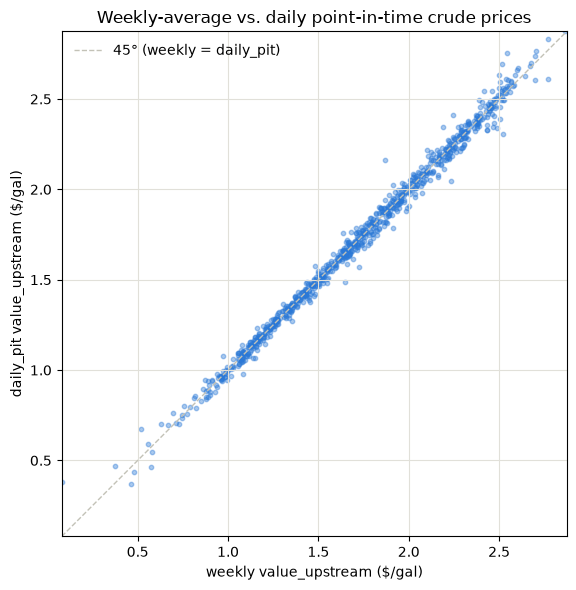

In [6]:
weekly_vs_daily = weekly[["date", "value_upstream"]].merge(
    daily_pit[["date", "value_upstream"]], on="date", suffixes=("_weekly", "_daily_pit")
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(weekly_vs_daily["value_upstream_weekly"], weekly_vs_daily["value_upstream_daily_pit"], s=10, alpha=0.4, color="#2a78d6")

lims = [
    min(weekly_vs_daily["value_upstream_weekly"].min(), weekly_vs_daily["value_upstream_daily_pit"].min()),
    max(weekly_vs_daily["value_upstream_weekly"].max(), weekly_vs_daily["value_upstream_daily_pit"].max()),
]
ax.plot(lims, lims, color="#c3c2b7", linewidth=1, linestyle="--", label="45° (weekly = daily_pit)")

ax.set_xlabel("weekly value_upstream ($/gal)")
ax.set_ylabel("daily_pit value_upstream ($/gal)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False)
ax.set_title("Weekly-average vs. daily point-in-time crude prices", loc="center")
plt.tight_layout()
plt.show()

In [7]:
corr = weekly_vs_daily["value_upstream_weekly"].corr(weekly_vs_daily["value_upstream_daily_pit"])
mad = (weekly_vs_daily["value_upstream_weekly"] - weekly_vs_daily["value_upstream_daily_pit"]).abs().mean()

print(f"n = {len(weekly_vs_daily)}")
print(f"correlation: {corr:.4f}")
print(f"mean absolute difference: {mad:.4f} $/gal")

n = 865
correlation: 0.9962
mean absolute difference: 0.0296 $/gal


## 3. Gap distribution
The `daily_pit` alignment does not differ from the weekly alignment on every week. For most observations, the last trading day before the Monday retail survey is the Friday immediately before it. The two alignments therefore produce the same date for 831 of 865 weeks.

The remaining 34 weeks are exceptions caused by holidays. In these cases, the last trading day before the Monday survey falls more than three calendar days earlier, creating a gap of 4 or 5 days between the upstream observation and the retail survey.

In [8]:
for name, df in ALIGNMENTS.items():
    print(f"--- {name} ---")
    print(df["gap_days"].value_counts(dropna=False).sort_index())
    print()

--- weekly ---
gap_days
3    865
Name: count, dtype: int64

--- daily_pit ---
gap_days
3    831
4     30
5      4
Name: count, dtype: int64

--- leaky ---
gap_days
-4.0    864
 NaN      1
Name: count, dtype: int64



In [9]:
irregular_weekly = weekly[weekly["gap_days"] != 3][["date", "upstream_date", "gap_days"]]
print(f"weekly: {len(irregular_weekly)} rows with gap_days != 3")
irregular_weekly

weekly: 0 rows with gap_days != 3


,date,upstream_date,gap_days


In [10]:
irregular_daily_pit = daily_pit[daily_pit["gap_days"] != 3][["date", "upstream_date", "gap_days"]]
print(f"daily_pit: {len(irregular_daily_pit)} rows with gap_days != 3")
irregular_daily_pit

daily_pit: 34 rows with gap_days != 3


,date,upstream_date,gap_days
12,2010-04-05,2010-04-01,4
50,2010-12-27,2010-12-23,4
67,2011-04-25,2011-04-21,4
117,2012-04-09,2012-04-05,4
168,2013-04-01,2013-03-28,4
223,2014-04-21,2014-04-17,4
234,2014-07-07,2014-07-03,4
273,2015-04-06,2015-04-02,4
286,2015-07-06,2015-07-02,4
311,2015-12-28,2015-12-24,4


The `gap=4` dates cluster around early April (Good Friday) and late December (Christmas week). The `gap=5` dates are concentrated in late November (Thanksgiving week), with one additional date in early July (Independence Day week). These patterns are consistent with the US trading-calendar holidays rather than with missing observations or an irregularity in the alignment itself.

## 4. Verify the look-ahead guard
The deliberately leaky alignment is passed to the same look-ahead check used by the alignment
logic. The check should reject any row where the upstream observation is not strictly earlier than
the retail survey date.

The public `align_retail_to_upstream` function uses a backward `merge_asof`, so it cannot itself
construct the deliberately leaky pairing. To test the guard against the exact failure mode this
notebook is designed to prevent, the already-constructed leaky DataFrame is therefore passed
directly to the internal validation function.

What this shows: the guard catches the specific future-date violation that would otherwise
introduce look-ahead bias.

In [11]:
from src.point_in_time import _check_no_look_ahead

print(f"upstream_date >= date (or NaT) on {(~(leaky['upstream_date'] < leaky['date'])).sum()} of {len(leaky)} rows")

try:
    _check_no_look_ahead(leaky)
    print("no error raised — unexpected, since `leaky` should violate the guard on nearly every row")
except ValueError as exc:
    print(f"{type(exc).__name__}: {exc}")

upstream_date >= date (or NaT) on 865 of 865 rows
ValueError: point_in_time.align_retail_to_upstream: found rows where upstream_date is not strictly before the retail date — either a look-ahead leak or no upstream match at all (NaT):
         date upstream_date
0  2010-01-11    2010-01-15
1  2010-01-18    2010-01-22
2  2010-01-25    2010-01-29
3  2010-02-01    2010-02-05
4  2010-02-08    2010-02-12
5  2010-02-15    2010-02-19
6  2010-02-22    2010-02-26
7  2010-03-01    2010-03-05
8  2010-03-08    2010-03-12
9  2010-03-15    2010-03-19
10 2010-03-22    2010-03-26
11 2010-03-29    2010-04-02
12 2010-04-05    2010-04-09
13 2010-04-12    2010-04-16
14 2010-04-19    2010-04-23
15 2010-04-26    2010-04-30
16 2010-05-03    2010-05-07
17 2010-05-10    2010-05-14
18 2010-05-17    2010-05-21
19 2010-05-24    2010-05-28
... (845 more rows not shown, 865 total)


## 5. Timeline
Retail prices and both upstream measures are plotted on the same timeline for a six-month window.
The selected survey Monday and the upstream observations used by the two valid alignments are marked
explicitly.

What this shows: how the two point-in-time alignments relate to the underlying daily and weekly
upstream series, and how the weekly average smooths movements that occur within a week.

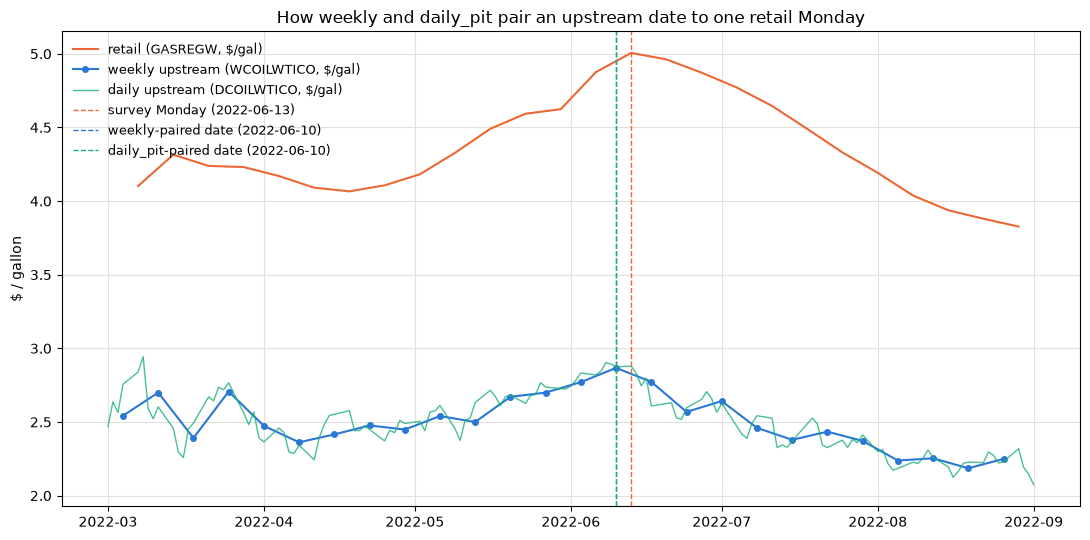

In [12]:
WINDOW_START = pd.Timestamp("2022-03-01")
WINDOW_END = pd.Timestamp("2022-09-01")

retail_window = retail[(retail["date"] >= WINDOW_START) & (retail["date"] <= WINDOW_END)]
weekly_upstream_window = weekly_upstream[(weekly_upstream["date"] >= WINDOW_START) & (weekly_upstream["date"] <= WINDOW_END)]
daily_upstream_window = daily_upstream[(daily_upstream["date"] >= WINDOW_START) & (daily_upstream["date"] <= WINDOW_END)]

weekly_marked_row = weekly[weekly["date"] == EXAMPLE_DATE].iloc[0]
daily_pit_marked_row = daily_pit[daily_pit["date"] == EXAMPLE_DATE].iloc[0]

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(retail_window["date"], retail_window["value"], color=COLOR_RETAIL, linewidth=1.5, label="retail (GASREGW, $/gal)")
ax.plot(weekly_upstream_window["date"], weekly_upstream_window["value"], color=COLOR_WEEKLY, linewidth=1.5, marker="o", markersize=4, label="weekly upstream (WCOILWTICO, $/gal)")
ax.plot(daily_upstream_window["date"], daily_upstream_window["value"], color=COLOR_DAILY_PIT, linewidth=1, alpha=0.8, label="daily upstream (DCOILWTICO, $/gal)")

ax.axvline(weekly_marked_row["date"], color=COLOR_RETAIL, linestyle="--", linewidth=1, label=f"survey Monday ({weekly_marked_row['date'].date()})")
ax.axvline(weekly_marked_row["upstream_date"], color=COLOR_WEEKLY, linestyle="--", linewidth=1, label=f"weekly-paired date ({weekly_marked_row['upstream_date'].date()})")
ax.axvline(daily_pit_marked_row["upstream_date"], color=COLOR_DAILY_PIT, linestyle="--", linewidth=1, label=f"daily_pit-paired date ({daily_pit_marked_row['upstream_date'].date()})")

ax.set_ylabel("$ / gallon")
ax.grid(True, color="#e1e0d9")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.set_title("How weekly and daily_pit pair an upstream date to one retail Monday", loc="center")

plt.tight_layout()
plt.show()

On this example week, the `weekly` and `daily_pit` alignments use the same upstream date (`2022-06-10`), so the two dashed lines overlap rather than appearing as separate lines. This is not a plotting issue: the two alignments coincide for 831 of 865 weeks (see Section 3) and differ only in the 34 holiday weeks identified there.

To see the difference visually, `EXAMPLE_DATE` can be set to one of those holiday weeks, for example `2022-04-18`, the week following Good Friday. The two dashed lines will then use different upstream dates and appear separately.